In [3]:
from qiskit import *
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
%matplotlib inline

In [26]:
def black_box_function(circuit, mode):
    '''
    Black box function Uf that can be changed to make it a balanced or unbalanced function.
    '''
    if mode == "const0":
        pass
    elif mode == "const1":
        circuit.x(1)
    else:
        circuit.cx(0, 1)

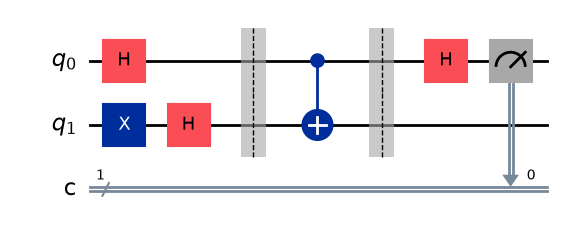

In [38]:
c = QuantumCircuit(2, 1)

c.h(0)
c.x(1)
c.h(1)
c.barrier()

black_box_function(c, "balanced")
c.barrier()

c.h(0)
c.measure(0, 0)

c.draw(output="mpl");

In [39]:
simulator = AerSimulator()
result = simulator.run(c, shots=1024).result()
counts = result.get_counts()

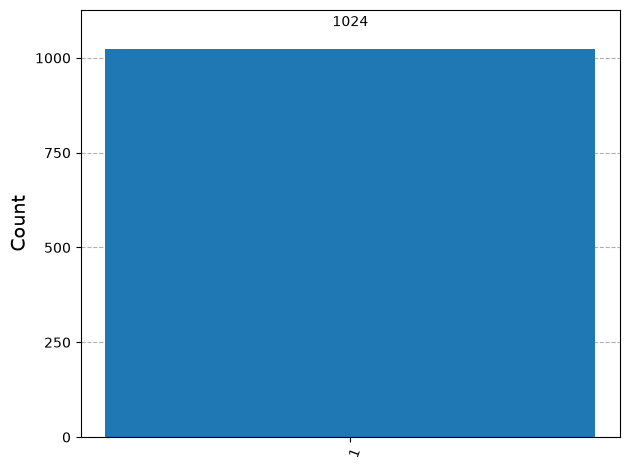

In [40]:
# q0 = 1 means balanced, q0 = 0 means constant
plot_histogram(counts);

In [37]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

for backend in service.backends():
    try:
        qubit_count = backend.num_qubits
    except:
        qubit_count = "unknown"
    
    print(f"{backend.name} : {backend.status().pending_jobs} & {qubit_count} qubits")

qiskit_runtime_service.__init__:WARNING:2026-09-19 18:36:40,981: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-19 18:36:40,993: Loading instance: open-instance, plan: open


KeyboardInterrupt: 

In [25]:
quantum_computer = service.backend("ibm_marrakesh")

qiskit_runtime_service.backends:WARNING:2026-09-19 18:33:42,771: Using instance: open-instance, plan: open


In [30]:
from qiskit_ibm_runtime import SamplerV2

transpiled_circuit = transpile(c, quantum_computer)
sampler = SamplerV2(mode=quantum_computer)
job = sampler.run([transpiled_circuit], shots=1024)

In [32]:
print(job.status())

DONE


In [33]:
result = job.result()
counts = result[0].data.c.get_counts()

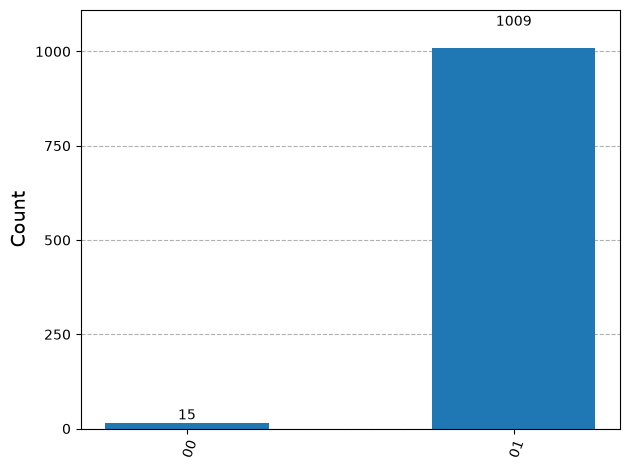

In [34]:
plot_histogram(counts);